# Generation 1 — DNN Baseline

In [1]:
!pip install -q tensorflow==2.15.0 keras==2.15.0

ERROR: Could not find a version that satisfies the requirement tensorflow==2.15.0 (from versions: 2.16.0rc0, 2.16.1, 2.16.2, 2.17.0rc0, 2.17.0rc1, 2.17.0, 2.17.1, 2.18.0rc0, 2.18.0rc1, 2.18.0rc2, 2.18.0, 2.18.1, 2.19.0rc0, 2.19.0, 2.19.1, 2.20.0rc0, 2.20.0, 2.21.0rc0, 2.21.0rc1, 2.21.0)
ERROR: No matching distribution found for tensorflow==2.15.0


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.optimizers import SGD, Adam
from tensorflow.keras.callbacks import EarlyStopping

In [4]:
!unzip /content/archive.zip -d /content/dataset

Streaming output truncated to the last 5000 lines.
  inflating: /content/dataset/training_setB/training_setB/p115003.psv  
  inflating: /content/dataset/training_setB/training_setB/p115004.psv  
  inflating: /content/dataset/training_setB/training_setB/p115005.psv  
  inflating: /content/dataset/training_setB/training_setB/p115006.psv  
  inflating: /content/dataset/training_setB/training_setB/p115007.psv  
  inflating: /content/dataset/training_setB/training_setB/p115008.psv  
  inflating: /content/dataset/training_setB/training_setB/p115009.psv  
  inflating: /content/dataset/training_setB/training_setB/p115010.psv  
  inflating: /content/dataset/training_setB/training_setB/p115011.psv  
  inflating: /content/dataset/training_setB/training_setB/p115012.psv  
  inflating: /content/dataset/training_setB/training_setB/p115013.psv  
  inflating: /content/dataset/training_setB/training_setB/p115014.psv  
  inflating: /content/dataset/training_setB/training_setB/p115015.psv  
  inflating: 

In [5]:
df = pd.read_csv('/content/dataset/Dataset.csv')
df = df.sample(20000, random_state=42)

In [10]:
numerical_columns = df.select_dtypes(include=np.number).columns
imputer = SimpleImputer(strategy='median')
df[numerical_columns] = imputer.fit_transform(df[numerical_columns])

df['SBP'] = df['SBP'].replace(0, 0.01)
df['ShockIndex'] = df['HR'] / df['SBP']
df['PulsePressure'] = df['SBP'] - df['DBP']
df['LowOxygenFlag'] = (df['O2Sat'] < 90).astype(int)

df.replace([np.inf, -np.inf], np.nan, inplace=True)
df = df.fillna(df.median(numeric_only=True))

X = df.drop(['SepsisLabel','Patient_ID'], axis=1)
y = df['SepsisLabel']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X).astype(np.float32)

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_scaled, y = smote.fit_resample(
    X_scaled,
    y
)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [11]:
def create_dnn_model(optimizer):

    model = Sequential([
        Input(shape=(X_train.shape[1],)),
        Dense(256, activation='relu'),
        BatchNormalization(),
        Dropout(0.4),
        Dense(128, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
    )

    return model

In [12]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(class_weights))

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

sgd_model = create_dnn_model(
    SGD(learning_rate=0.001, momentum=0.9)
)

history_sgd = sgd_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    class_weight=class_weights,
    callbacks=[early_stopping]
)

Epoch 1/20
786/786 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.6303 - loss: 0.6488 - precision_2: 0.6438 - recall_2: 0.5793 - val_accuracy: 0.7020 - val_loss: 0.5837 - val_precision_2: 0.7011 - val_recall_2: 0.7042
Epoch 2/20
786/786 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6761 - loss: 0.5984 - precision_2: 0.6942 - recall_2: 0.6266 - val_accuracy: 0.7308 - val_loss: 0.5571 - val_precision_2: 0.7358 - val_recall_2: 0.7202
Epoch 3/20
786/786 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6934 - loss: 0.5761 - precision_2: 0.7131 - recall_2: 0.6447 - val_accuracy: 0.7606 - val_loss: 0.5331 - val_precision_2: 0.7232 - val_recall_2: 0.8443
Epoch 4/20
786/786 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7091 - loss: 0.5577 - precision_2: 0.7237 - recall_2: 0.6740 - val_accuracy: 0.7693 - val_loss: 0.5141 - val_precision_2: 0.7135 - val_recall_2: 0.9000
Epoch 5/20
786/786 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.7230 - loss: 0.5420 - precision_2: 0.7318 - recall_2: 0.7016 -

In [13]:
adam_model = create_dnn_model(
    Adam(learning_rate=0.0001, clipnorm=1.0)
)

history_adam = adam_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    class_weight=class_weights,
    callbacks=[early_stopping]
)

predictions = adam_model.predict(X_test)
predictions = (predictions > 0.5).astype(int)

print("Accuracy:", accuracy_score(y_test, predictions))
print("Precision:", precision_score(y_test, predictions))
print("Recall:", recall_score(y_test, predictions))
print("F1:", f1_score(y_test, predictions))

Epoch 1/20
786/786 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.6148 - loss: 0.6740 - precision_3: 0.6158 - recall_3: 0.6054 - val_accuracy: 0.6839 - val_loss: 0.5857 - val_precision_3: 0.7682 - val_recall_3: 0.5266
Epoch 2/20
786/786 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6570 - loss: 0.6171 - precision_3: 0.6639 - recall_3: 0.6323 - val_accuracy: 0.7112 - val_loss: 0.5473 - val_precision_3: 0.7886 - val_recall_3: 0.5772
Epoch 3/20
786/786 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6911 - loss: 0.5819 - precision_3: 0.7021 - recall_3: 0.6612 - val_accuracy: 0.7472 - val_loss: 0.5185 - val_precision_3: 0.7965 - val_recall_3: 0.6641
Epoch 4/20
786/786 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.6985 - loss: 0.5661 - precision_3: 0.7059 - recall_3: 0.6780 - val_accuracy: 0.7689 - val_loss: 0.4973 - val_precision_3: 0.7973 - val_recall_3: 0.7211
Epoch 5/20
786/786 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.7178 - loss: 0.5451 - precision_3: 0.7233 - recall_3: 0.7032

In [15]:
sgd_predictions = sgd_model.predict(X_test)
sgd_predictions = (sgd_predictions > 0.5).astype(int)

print("Accuracy:", accuracy_score(y_test, sgd_predictions))
print("Precision:", precision_score(y_test, sgd_predictions))
print("Recall:", recall_score(y_test, sgd_predictions))
print("F1:", f1_score(y_test, sgd_predictions))

246/246 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Accuracy: 0.8636189991086209
Precision: 0.8004162330905307
Recall: 0.9717028802425467
F1: 0.8777815816501198


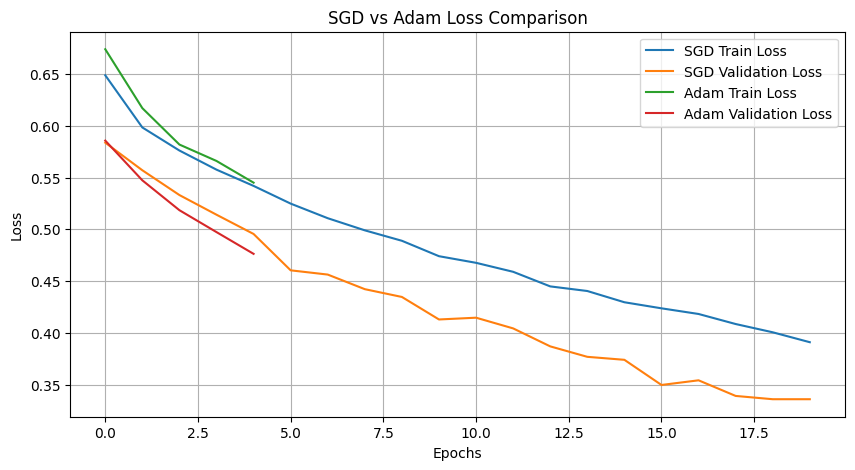

In [19]:
# =====================================================
# SGD vs ADAM LOSS CURVES
# =====================================================

plt.figure(figsize=(10,5))

# SGD Training Loss
plt.plot(
    history_sgd.history['loss'],
    label='SGD Train Loss'
)

# SGD Validation Loss
plt.plot(
    history_sgd.history['val_loss'],
    label='SGD Validation Loss'
)

# Adam Training Loss
plt.plot(
    history_adam.history['loss'],
    label='Adam Train Loss'
)

# Adam Validation Loss
plt.plot(
    history_adam.history['val_loss'],
    label='Adam Validation Loss'
)

plt.xlabel("Epochs")

plt.ylabel("Loss")

plt.title("SGD vs Adam Loss Comparison")

plt.legend()

plt.grid(True)

plt.show()

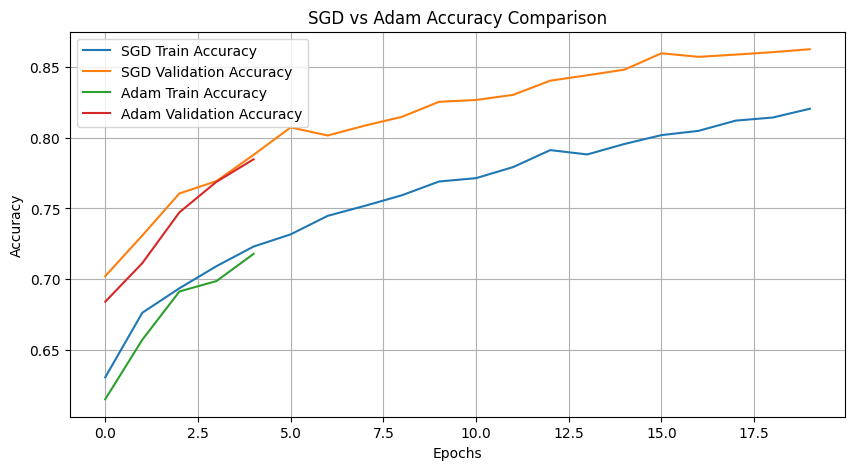

In [20]:
# =====================================================
# SGD vs ADAM ACCURACY CURVES
# =====================================================

plt.figure(figsize=(10,5))

# SGD Accuracy
plt.plot(
    history_sgd.history['accuracy'],
    label='SGD Train Accuracy'
)

plt.plot(
    history_sgd.history['val_accuracy'],
    label='SGD Validation Accuracy'
)

# Adam Accuracy
plt.plot(
    history_adam.history['accuracy'],
    label='Adam Train Accuracy'
)

plt.plot(
    history_adam.history['val_accuracy'],
    label='Adam Validation Accuracy'
)

plt.xlabel("Epochs")

plt.ylabel("Accuracy")

plt.title("SGD vs Adam Accuracy Comparison")

plt.legend()

plt.grid(True)

plt.show()

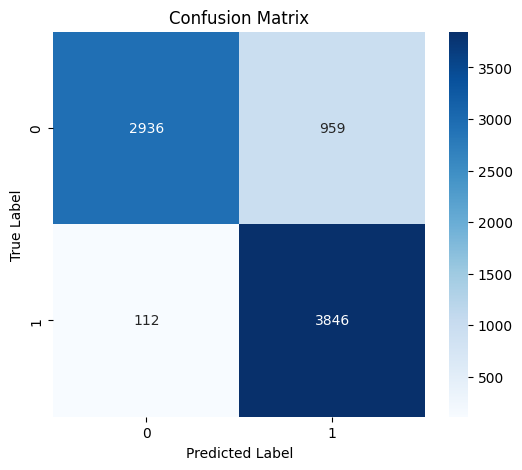

In [16]:
# =====================================================
# CONFUSION MATRIX
# =====================================================

cm = confusion_matrix(
    y_test,
    sgd_predictions
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted Label")

plt.ylabel("True Label")

plt.title("Confusion Matrix")

plt.show()

In [17]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        sgd_predictions
    )
)

              precision    recall  f1-score   support

         0.0       0.96      0.75      0.85      3895
         1.0       0.80      0.97      0.88      3958

    accuracy                           0.86      7853
   macro avg       0.88      0.86      0.86      7853
weighted avg       0.88      0.86      0.86      7853



In [18]:
# =====================================================
# SAVE DNN MODEL
# =====================================================

sgd_model.save(
    'dnn_sepsis_model.h5'
)

print("DNN model saved successfully")

DNN model saved successfully
